#### Calcullating Model Accuracy

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import load_model
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Year 2001
jan_apr_2001 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2001\Jan_Apr_2001\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2001 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2001\Jan_Apr_2001\data_stream-oper_stepType-accum.nc")
may_aug_2001 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2001\May_Aug_2001\data_stream-oper_stepType-instant.nc")
may_aug_prep_2001 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2001\May_Aug_2001\data_stream-oper_stepType-accum.nc")
sep_dec_2001 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2001\Sep_Dec_2001\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2001 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2001\Sep_Dec_2001\data_stream-oper_stepType-accum.nc")
# Year 2007
jan_apr_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Jan_Apr_2007\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Jan_Apr_2007\data_stream-oper_stepType-accum.nc")
may_aug_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\May_Aug_2007\data_stream-oper_stepType-instant.nc")
may_aug_prep_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\May_Aug_2007\data_stream-oper_stepType-accum.nc")
sep_dec_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Sep_Dec_2007\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Sep_Dec_2007\data_stream-oper_stepType-accum.nc")

In [3]:
data_2001 = [jan_apr_2001,may_aug_2001,sep_dec_2001]
data_prep_2001 = [jan_apr_prep_2001,may_aug_prep_2001,sep_dec_prep_2001]

data_2007 = [jan_apr_2007,may_aug_2007,sep_dec_2007]
data_prep_2007 = [jan_apr_prep_2007,may_aug_prep_2007,sep_dec_prep_2007]

In [4]:
# Concatenate along valid_time
data_2001 = xr.concat(data_2001, dim="valid_time")
prep_2001 = xr.concat(data_prep_2001, dim="valid_time")

In [5]:
temperature_2m = data_2001['t2m']
sea_level_pressure = data_2001['msl']
sea_surface_temp = data_2001['sst']
Qu = data_2001['viwve']
Qv = data_2001['viwvn']
precip = prep_2001['tp']
# Replace NaN values in sea_surface_temp with t2m values
sst_filled = sea_surface_temp.fillna(temperature_2m)

In [6]:
# Regularize time to hourly grid
full_time = pd.date_range(
    '2001-01-01 00:00:00',
    '2001-12-31 23:00:00',
    freq='h'
)

precip = precip.reindex(valid_time=full_time, method='ffill')
msl = sea_level_pressure.reindex(valid_time=full_time, method='ffill')
sst = sst_filled.reindex(valid_time=full_time, method='ffill')
Qu = Qu.reindex(valid_time=full_time, method='ffill')
Qv = Qv.reindex(valid_time=full_time, method='ffill')

In [7]:
precip_1D = precip.resample(valid_time='1D').sum()
msl_1D = msl.resample(valid_time='1D').mean()
sst_1D = sst.resample(valid_time='1D').mean()
Qu_1D = Qu.resample(valid_time='1D').mean()
Qv_1D = Qv.resample(valid_time='1D').mean()

In [8]:
# Create Daily Dataset
ds_daily = xr.Dataset({
    'tp': precip_1D * 1000,   # mm/day
    'msl': msl_1D,
    'sst': sst_1D,
    'Qu': Qu_1D,
    'Qv': Qv_1D
})

In [9]:
# Process each year separately
years = [2001]
monsoon_datasets = []
WINDOW = 7
LAG = 1
for year in years:
    # Extract monsoon season for each year
    start_date = f'{year}-05-01'
    end_date = f'{year}-09-30'
    
    # Get daily data for this year's monsoon
    ds_year = ds_daily.sel(valid_time=slice(start_date, end_date))
    
    # Apply weekly smoothing
    ds_year_weekly = xr.Dataset({
        'tp': ds_year['tp'].rolling(valid_time=WINDOW).mean(),
        'msl': ds_year['msl'].rolling(valid_time=WINDOW).mean(),
        'sst': ds_year['sst'].rolling(valid_time=WINDOW).mean(),
        'Qu': ds_year['Qu'].rolling(valid_time=WINDOW).mean(),
        'Qv': ds_year['Qv'].rolling(valid_time=WINDOW).mean()
    })
    
    # Calculate Qmag
    ds_year_weekly['Qmag'] = np.sqrt(ds_year_weekly['Qu']**2 + ds_year_weekly['Qv']**2)
    
    # Add lag features
    for v in ['tp','msl', 'sst', 'Qu', 'Qv', 'Qmag']:
        ds_year_weekly[f'{v}_lag1'] = ds_year_weekly[v].shift(valid_time=LAG)
    
    monsoon_datasets.append(ds_year_weekly)

# Concatenate all years
ds_monsoon_weekly_all = xr.concat(monsoon_datasets, dim='valid_time')
ds_monsoon_weekly_all = ds_monsoon_weekly_all.dropna('valid_time')

In [10]:
print(f"Processed {len(years)} monsoon seasons separately")
print(f"Total monsoon days across all years: {len(ds_monsoon_weekly_all.valid_time)}")

Processed 1 monsoon seasons separately
Total monsoon days across all years: 146


In [11]:
ds_monsoon_weekly_all

<xarray.Dataset> Size: 96MB
Dimensions:     (valid_time: 146, latitude: 121, longitude: 113)
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 968B 30.0 29.75 29.5 29.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 904B 72.0 72.25 72.5 ... 99.5 99.75 100.0
  * valid_time  (valid_time) datetime64[ns] 1kB 2001-05-08 ... 2001-09-30
Data variables:
    tp          (valid_time, latitude, longitude) float32 8MB 0.001635 ... 10.3
    msl         (valid_time, latitude, longitude) float32 8MB 9.99e+04 ... 1....
    sst         (valid_time, latitude, longitude) float32 8MB 308.4 ... 297.2
    Qu          (valid_time, latitude, longitude) float32 8MB 57.05 ... -10.89
    Qv          (valid_time, latitude, longitude) float32 8MB -9.629 ... -49.9
    Qmag        (valid_time, latitude, longitude) float32 8MB 57.85 ... 51.08
    tp_lag1     (valid_time, latitude, longitude) float32 8MB 0.1657 ... 10.5
    msl_lag1    (valid_time, latitude, longitude) float32 8MB 9.993e+04 ... 1...
    sst_lag1    (valid_time, latitude, longitude) float32 8MB 308.4 ... 297.2
    Qu_lag1     (valid_time, latitude, longitude) float32 8MB 74.57 ... -16.0
    Qv_lag1     (valid_time, latitude, longitude) float32 8MB -7.438 ... -34.41
    Qmag_lag1   (valid_time, latitude, longitude) float32 8MB 74.94 ... 37.94

In [12]:
ds_monsoon_weekly_all['tp_log'] = np.log1p(ds_monsoon_weekly_all['tp'])

In [13]:
features = ['tp','msl', 'sst', 'Qu', 'Qv', 'Qmag']
features_lagged = features + [f'{v}_lag1' for v in features]

In [14]:
ds = ds_monsoon_weekly_all

means = {}
stds = {}

for v in features_lagged:
    means[v] = ds[v].mean(dim=('valid_time','latitude','longitude'))
    stds[v]  = ds[v].std(dim=('valid_time','latitude','longitude'))

ds_norm = ds_monsoon_weekly_all.copy()

for v in features_lagged:
    ds_norm[v] = (ds_monsoon_weekly_all[v] - means[v]) / stds[v]

ds_norm = ds_norm.fillna(0.0)
ds_norm_val = ds_norm

In [15]:
times = ds_norm.valid_time.values

val_times = times
SEQ_LEN = 7

X_seq_val = []
y_val = []
pred_times = []

for t in val_times:
    # index of target time
    ti = np.where(times == t)[0][0]

    # need SEQ_LEN history
    if ti < SEQ_LEN:
        continue

    t_seq = times[ti-SEQ_LEN:ti]

    X = ds_norm[features_lagged].sel(valid_time=t_seq).to_array().values
    X = np.moveaxis(X, 0, -1)   # (time, lat, lon, features)

    y = ds_norm['tp_log'].sel(valid_time=t).values

    X_seq_val.append(X)
    y_val.append(y)
    pred_times.append(t)

X_seq_val = np.array(X_seq_val, dtype=np.float32)
y_val     = np.array(y_val, dtype=np.float32)


In [16]:
def masked_mse(y_true, y_pred):
    mask = tf.cast(y_true > 0, tf.float32)
    return tf.reduce_sum(mask * tf.square(y_true - y_pred)) / (
        tf.reduce_sum(mask) + 1e-6
    )

In [17]:
regressor_4 = load_model(
    r"D:\Heavy Monsoon\Model Accuracy\Model\convlstm_unet_May_Sep_regressor_rain_model_4.keras",
    custom_objects={"masked_mse": masked_mse}
)

In [18]:
log_rain_4 = regressor_4.predict(X_seq_val)
rain_amt_4 = np.expm1(log_rain_4)
pred_single_4 = rain_amt_4

5/5 [==============================] - 174s 32s/step


In [19]:
times_aligned = np.array(pred_times)
rain_true = (
    ds_monsoon_weekly_all['tp']
    .sel(valid_time=pred_times)
    .values
)
pred_single_4 = pred_single_4.squeeze()   # (time, lat, lon)
obs_mean = rain_true.mean(axis=(1, 2))
pred_mean_single_4 = pred_single_4.mean(axis=(1, 2))
print(times_aligned.shape)
print(obs_mean.shape)
print(pred_mean_single_4.shape)


(139,)
(139,)
(139,)


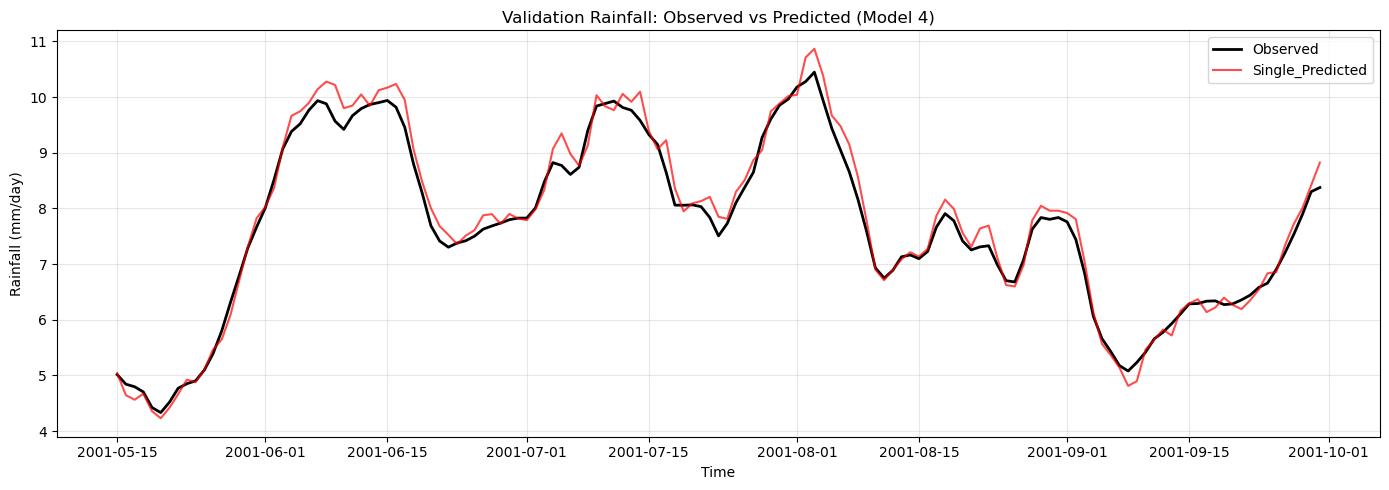

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(pred_times, obs_mean, label='Observed', color='black', linewidth=2)
plt.plot(pred_times, pred_mean_single_4, label='Single_Predicted', color='red', alpha=0.7)
plt.ylabel('Rainfall (mm/day)')
plt.xlabel('Time')
plt.title('Validation Rainfall: Observed vs Predicted (Model 4)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

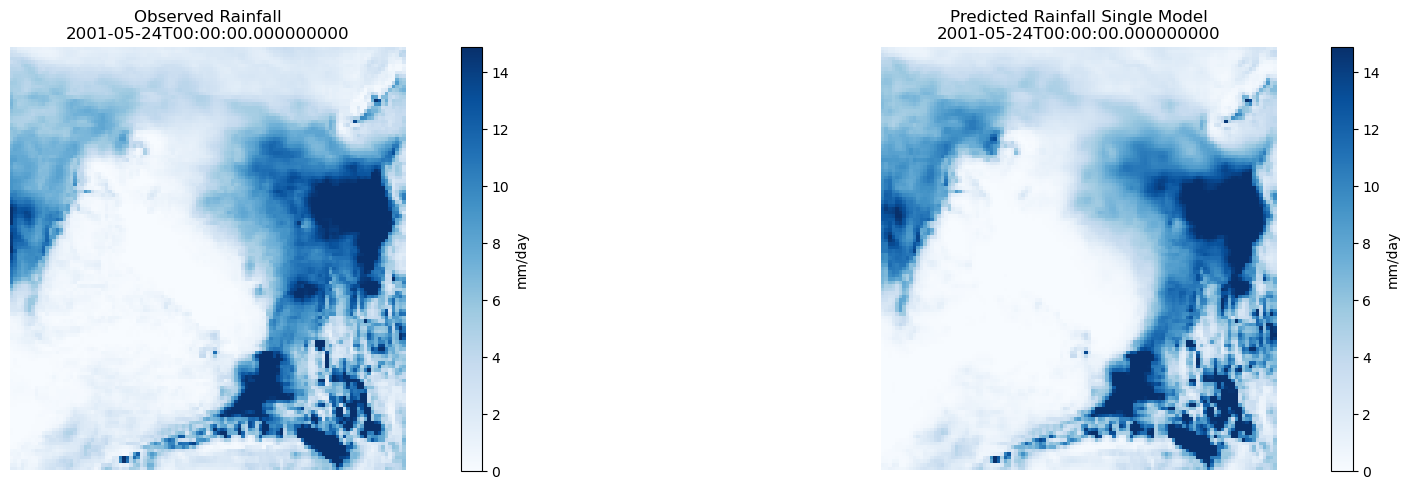

In [21]:
t_idx = 9  # any validation index

obs_map  = rain_true[t_idx]
pred_map_single_4 = pred_single_4[t_idx]

vmax = np.percentile(obs_map, 95)

plt.figure(figsize=(20, 5))

# Observed
plt.subplot(1, 2, 1)
plt.imshow(obs_map, origin='lower', cmap='Blues', vmin=0, vmax=vmax)
plt.colorbar(label='mm/day')
plt.title(f'Observed Rainfall\n{pred_times[t_idx]}')
plt.axis('off')

# Predicted by Single model
plt.subplot(1, 2, 2)
plt.imshow(pred_map_single_4, origin='lower', cmap='Blues', vmin=0, vmax=vmax)
plt.colorbar(label='mm/day')
plt.title(f'Predicted Rainfall Single Model\n{pred_times[t_idx]}')
plt.axis('off')



plt.tight_layout()
plt.show()


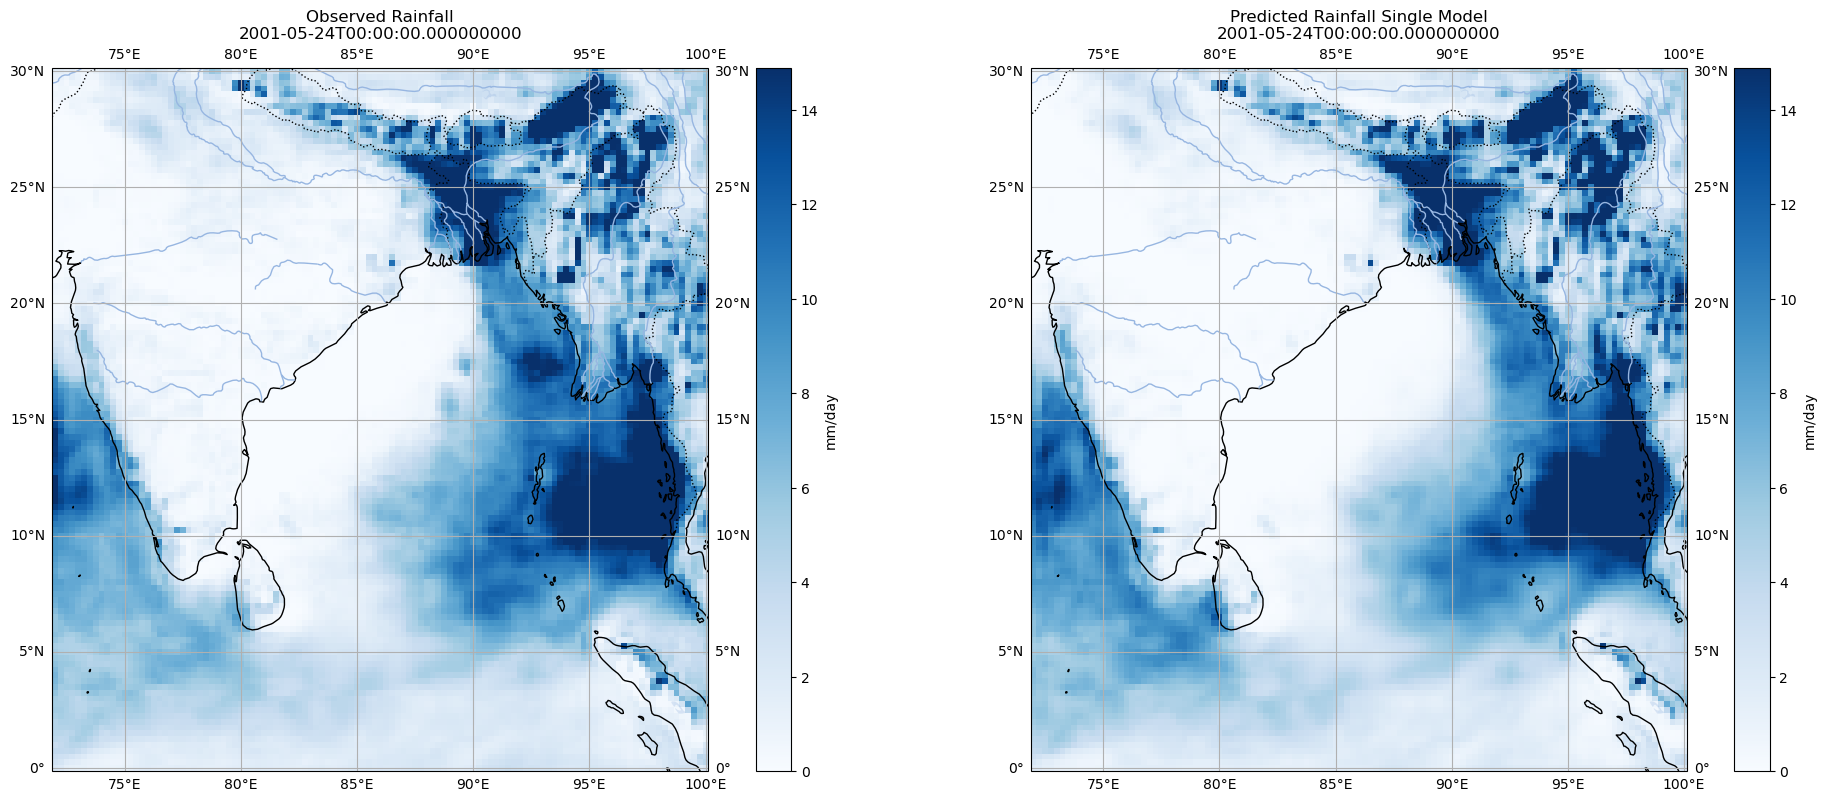

In [22]:
# Example t_idx
t_idx = 9  # any validation index

# Observed and predicted maps
obs_map = rain_true[t_idx]
pred_map_single_4 = pred_single_4[t_idx]

# Spatial coordinates
lats = ds.latitude.values
lons = ds.longitude.values

# vmax for color scale
vmax = np.percentile(obs_map, 95)

# Figure
fig, axes = plt.subplots(
    1, 2, figsize=(20, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# ----------- Observed Rainfall -----------
ax = axes[0]
im0 = ax.pcolormesh(
    lons, lats, obs_map,
    cmap='Blues', vmin=0, vmax=vmax,
    shading='auto', transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.add_feature(cfeature.RIVERS)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.set_title(f'Observed Rainfall\n{pred_times[t_idx]}')
fig.colorbar(im0, ax=ax, orientation='vertical', label='mm/day')

# ----------- Predicted Rainfall (Single Model) -----------
ax = axes[1]
im1 = ax.pcolormesh(
    lons, lats, pred_map_single_4,
    cmap='Blues', vmin=0, vmax=vmax,
    shading='auto', transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.add_feature(cfeature.RIVERS)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.set_title(f'Predicted Rainfall Single Model\n{pred_times[t_idx]}')
fig.colorbar(im1, ax=ax, orientation='vertical', label='mm/day')

plt.tight_layout()
plt.show()


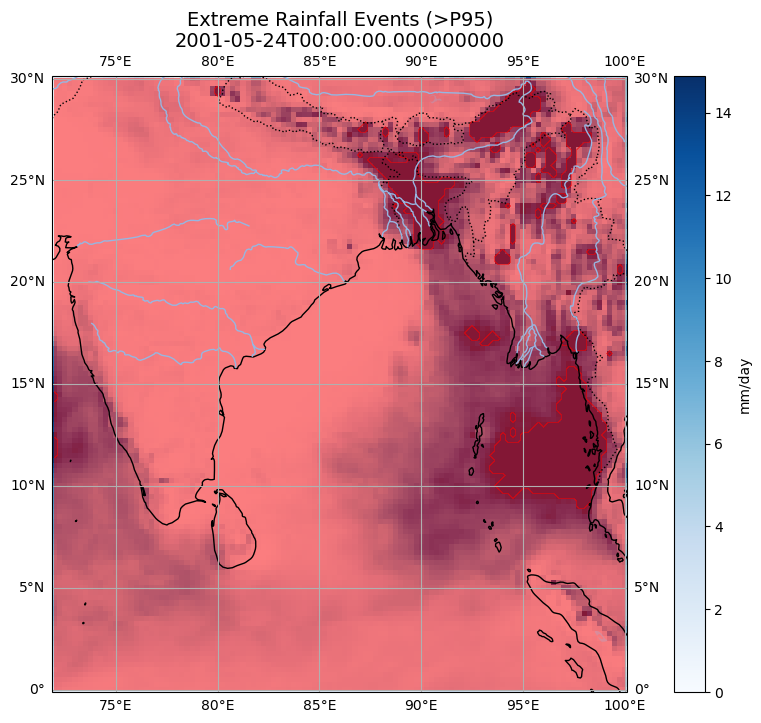

In [23]:
t_idx = 9  # validation index
obs_map = rain_true[t_idx]        # observed rainfall
pred_map = pred_single_4[t_idx]   # predicted rainfall (single model)
lats = ds.latitude.values
lons = ds.longitude.values

# 1️⃣ Extreme rainfall (>P95) map
# -------------------------------
extreme_threshold = np.percentile(obs_map, 95)

fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot rainfall
im = ax.pcolormesh(
    lons, lats, obs_map,
    cmap='Blues', vmin=0, vmax=np.percentile(obs_map, 95),
    shading='auto', transform=ccrs.PlateCarree()
)

# Overlay extreme rainfall events
extreme_mask = obs_map >= extreme_threshold
ax.contourf(
    lons, lats, extreme_mask,
    colors='red', alpha=0.5, transform=ccrs.PlateCarree()
)

# Add coastlines and other features
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES, alpha=0.3)

# Gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Colorbar
fig.colorbar(im, ax=ax, orientation='vertical', label='mm/day')

ax.set_title(f'Extreme Rainfall Events (>P95)\n{pred_times[t_idx]}', fontsize=14)
plt.show()


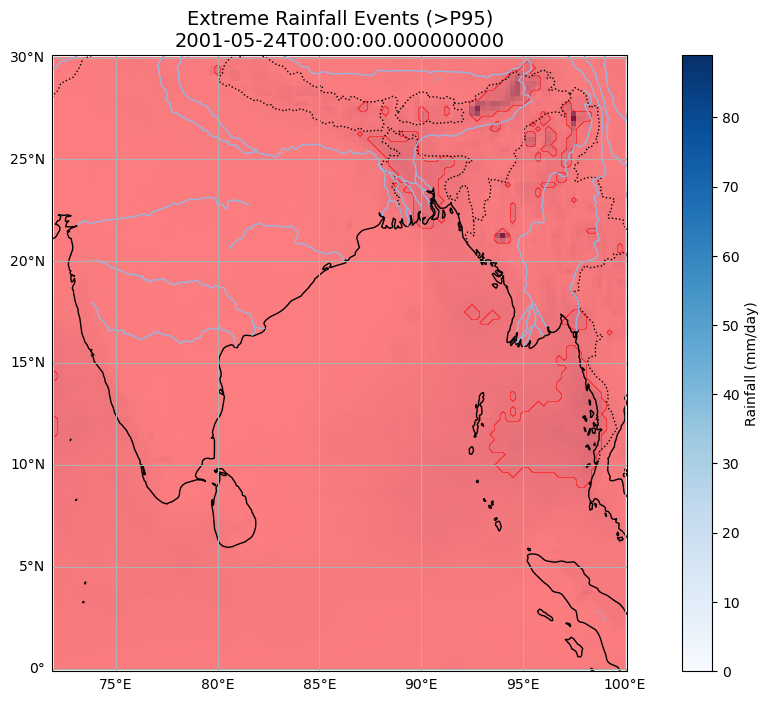

In [24]:
# -------------------------------
# Plotting
# -------------------------------
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 1️⃣ Plot all rainfall in blue scale
rain_plot = ax.pcolormesh(
    lons, lats, obs_map,
    cmap='Blues',
    shading='auto',
    transform=ccrs.PlateCarree()
)

# 2️⃣ Highlight extreme events (>P95) in semi-transparent red
extreme_mask = obs_map >= extreme_threshold
ax.contourf(
    lons, lats, extreme_mask,
    colors='red',
    alpha=0.5,
    transform=ccrs.PlateCarree()
)

# 3️⃣ Add coastlines, borders, rivers, lakes
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.LAKES, alpha=0.3)

# 4️⃣ Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# 5️⃣ Add colorbar
cbar = fig.colorbar(rain_plot, ax=ax, orientation='vertical', label='Rainfall (mm/day)')

# 6️⃣ Title
ax.set_title(f'Extreme Rainfall Events (>P95)\n{pred_times[t_idx]}', fontsize=14)

plt.show()

##### @@

In [28]:
y_true_mm = np.expm1(y_val)
y_pred_mm = np.expm1(log_rain_4)

y_true_mm = np.clip(y_true_mm, 0, None)
y_pred_mm = np.clip(y_pred_mm, 0, None)


In [36]:
y_pred_mm = y_pred_mm.squeeze()

In [37]:
# Valid rainfall mask (observed rain > 1 mm/day)
mask = y_true_mm > 1.0

corr = np.corrcoef(
    y_true_mm[mask].flatten(),
    y_pred_mm[mask].flatten()
)[0, 1]

print(f"Spatial correlation (>1 mm/day): {corr:.3f}")


Spatial correlation (>1 mm/day): 0.977


In [38]:
p95 = np.percentile(y_true_mm, 95)
mask = y_true_mm >= p95

corr = np.corrcoef(
    y_true_mm[mask].flatten(),
    y_pred_mm[mask].flatten()
)[0, 1]

print(f"Extreme rainfall correlation (P95): {corr:.3f}")

Extreme rainfall correlation (P95): 0.894


In [39]:
extreme_true = y_true_mm > p95
extreme_pred = y_pred_mm > p95

hits  = np.sum(extreme_true & extreme_pred)
miss  = np.sum(extreme_true & ~extreme_pred)
false = np.sum(~extreme_true & extreme_pred)

pod = hits / (hits + miss + 1e-6)     # Probability of detection
far = false / (hits + false + 1e-6)   # False alarm ratio

print(f"POD: {pod:.3f}")
print(f"FAR: {far:.3f}")

POD: 0.919
FAR: 0.205


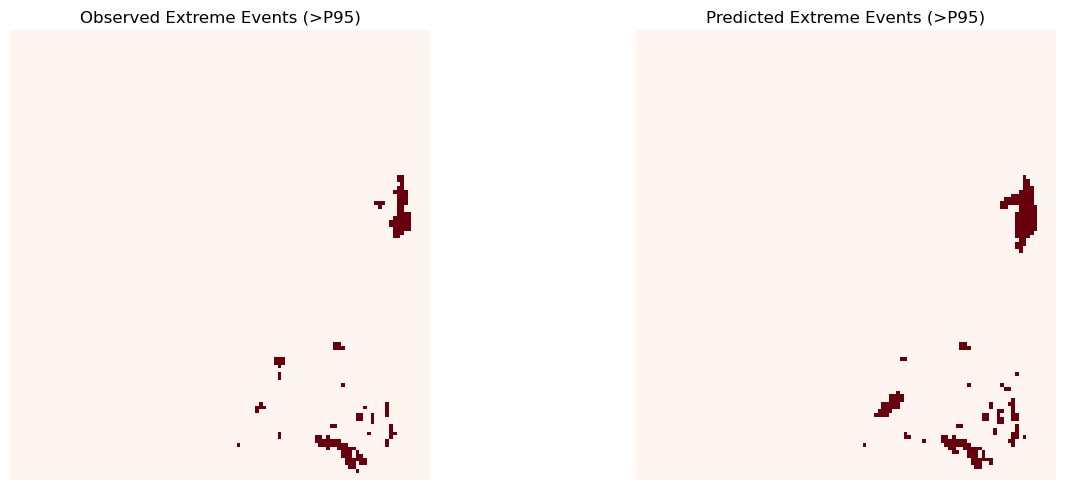

In [40]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(extreme_true[t_idx], origin="lower", cmap="Reds")
plt.title("Observed Extreme Events (>P95)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(extreme_pred[t_idx], origin="lower", cmap="Reds")
plt.title("Predicted Extreme Events (>P95)")
plt.axis("off")

plt.tight_layout()
plt.show()


###### CRPS for deterministic rainfall

In [41]:
def crps_deterministic(y_true, y_pred):
    """
    y_true, y_pred: (..., lat, lon)
    """
    return np.mean(np.abs(y_pred - y_true))

crps_det = crps_deterministic(y_true_mm, y_pred_mm)
print(f"Deterministic CRPS (mm/day): {crps_det:.3f}")

Deterministic CRPS (mm/day): 0.960


###### Spatially averaged CRPS

In [42]:
crps_daily = np.mean(
    np.abs(
        y_pred_mm.mean(axis=(1,2)) -
        y_true_mm.mean(axis=(1,2))
    )
)

print(f"Domain-mean CRPS (mm/day): {crps_daily:.3f}")

Domain-mean CRPS (mm/day): 0.174


###### CRPS for extreme rainfall only (VERY IMPORTANT)

In [43]:
p95 = np.percentile(y_true_mm, 95)
mask_extreme = y_true_mm >= p95
crps_extreme = np.mean(
    np.abs(
        y_pred_mm[mask_extreme] -
        y_true_mm[mask_extreme]
    )
)

print(f"Extreme (P95+) CRPS (mm/day): {crps_extreme:.3f}")

Extreme (P95+) CRPS (mm/day): 3.140


CRPS (mm/day)	Interpretation

< 3   	Excellent

3–6	    Good

6–10	Moderate

_>10	    Poor

For P95 extremes:

Anything < 15 mm/day is impressive